--- Dataset Sample Features ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


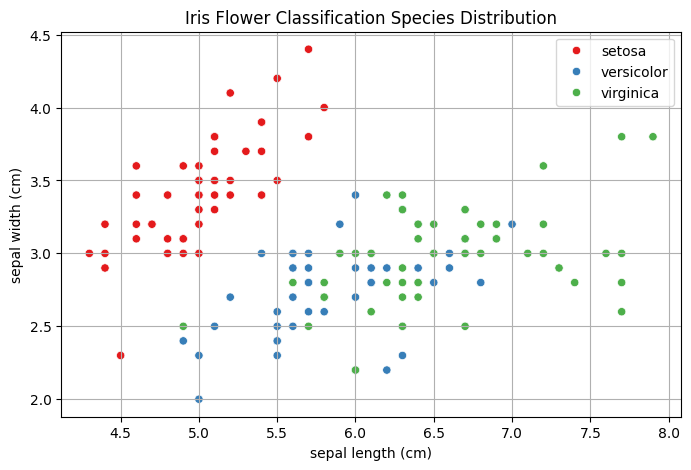


--- Model Evaluation Metrics ---
Overall Accuracy Score: 90.00%

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



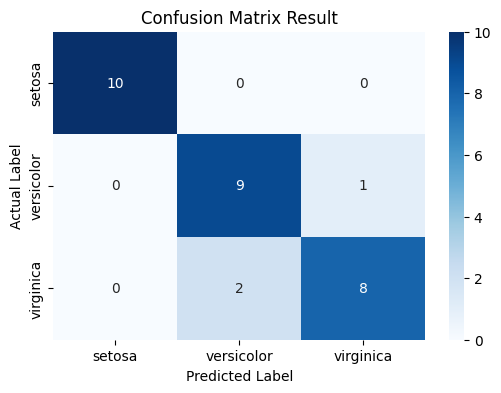

In [4]:
# ==========================================
# CODEALPHA DATA SCIENCE INTERNSHIP
# TASK 1: IRIS FLOWER CLASSIFICATION
# ==========================================

# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 2. Load the Dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("--- Dataset Sample Features ---")
print(X.head())

# 3. Exploratory Data Analysis (EDA) Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[iris.feature_names[0]], y=X[iris.feature_names[1]], hue=iris.target_names[y], palette='Set1')
plt.title('Iris Flower Classification Species Distribution')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.grid(True)
plt.show()

# 4. Data Splitting (Train and Test Sets)
# Fixed code line
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Model Training (Random Forest Classifier)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 7. Model Evaluation & Accuracy Checking
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Overall Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# 8. Confusion Matrix Plotting
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names, cmap='Blues')
plt.title('Confusion Matrix Result')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()